# Wavefront to PSF (v1)

**Author:** Aaron Roodman  
**Date Created:** 2026-03-19  
**Last Modified:** 2026-03-19  
**Status:** In Progress  
**Keywords:** PSF, Zernike, wavefront, focal plane, GalSim, FAM  

## Description

Generate PSF images from wavefront Zernike measurements across the focal plane.
Reads the per-donut and per-visit tables produced by `intrinsics_mktable`,
computes the median Zernike wavefront per detector per visit, and draws
PSF images using GalSim.

Key functionality:
1. Load Zernike wavefront tables from `aos/output/`
2. Compute median Zernike coefficients per detector per visit
3. Draw PSF from median wavefront using GalSim optical+atmospheric model
4. Produce one PNG per visit showing PSFs at detector positions on the focal plane

**Output:** PNG files in `psf/output/`, one per visit  
**Based on:** `intrinsics_mktable`, `intrinsics_plots`, `zernike_psf_moments`

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-03-19 | Aaron Roodman | Initial version |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Load Data](#data)
5. [Compute Median Zernikes per Detector](#median)
6. [Draw PSFs and Generate PNGs](#results)

<a id='params'></a>
## 1. Parameters

In [1]:
from pathlib import Path

# ============================================================
# Parameters — All configurable values collected here
# ============================================================

# Coordinate system: 'CCS' or 'OCS' (must match mktable choice)
coord_sys = 'OCS'

# Parquet file version strings (must match mktable output)
wep_ver = 'wep_v16_8_0'
dviz_ver = 'dviz_v3_5_0'

# Parquet file date range
day_obs_min = 20251020
day_obs_max = 20251231

# Visits to process: list of (day_obs, seq_num) tuples, or None for all
# Example: [(20251105, 52), (20251105, 53)]
selected_visits = None  # None = process all visits in table

# PSF drawing parameters
LAM_NM      = 500.0   # wavelength [nm]
DIAM_M      = 8.36    # primary mirror diameter [m]
OBSCURATION = 0.61    # central obscuration ratio
PIXEL_SCALE = 0.2     # arcsec/pixel
STAMP_SIZE  = 64      # PSF stamp size [pixels] (smaller for focal plane mosaic)

# Atmospheric turbulence
ATM_R0      = 0.1382  # Fried parameter r0 at 500 nm [m]
ATM_L0_M    = 30.0    # outer scale L0 [m]

# Paths
aos_output_dir = Path('../aos/output')
output_dir = Path('output')
output_dir.mkdir(parents=True, exist_ok=True)

<a id='setup'></a>
## 2. Setup & Imports

In [2]:
import sys
import numpy as np
import galsim
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import FancyBboxPatch
import matplotlib.cm as cm
from astropy.table import QTable
import warnings
warnings.filterwarnings('ignore')

# Add repo root for common imports
sys.path.insert(0, str(Path.cwd().parent))
from common.utils import setup_plotting
from common.camera_utils import get_detector_centers, RAFT_GRID, SENSOR_SLOTS

# LSST camera
from lsst.obs.lsst import LsstCam
import lsst.afw.cameraGeom as cameraGeom

camera = LsstCam.getCamera()

setup_plotting()
%matplotlib inline

LAM_MICRONS = LAM_NM / 1000.0
print(f'Camera: {len(list(camera))} detectors')

Camera: 205 detectors


<a id='functions'></a>
## 3. Helper Functions

In [3]:
def infer_zernike_indices(nZk):
    """Infer Noll Zernike indices from number of terms."""
    if nZk == 25:
        return list(range(4, 29))
    elif nZk == 21:
        return list(range(4, 20)) + list(range(22, 27))
    elif nZk == 19:
        return list(range(4, 23))
    else:
        return list(range(4, 4 + nZk))


def draw_psf(coeffs_um, nx=STAMP_SIZE, ny=STAMP_SIZE, scale=PIXEL_SCALE):
    """Draw total PSF (optical + atmosphere) from Zernike coefficients in microns.

    Parameters
    ----------
    coeffs_um : dict
        {noll_index: coefficient_in_microns}

    Returns
    -------
    galsim.Image
    """
    noll_max = max(coeffs_um.keys()) if coeffs_um else 4
    aberrations = np.zeros(noll_max + 1)
    for noll_j, coeff in coeffs_um.items():
        aberrations[noll_j] = coeff / LAM_MICRONS

    optical_psf = galsim.OpticalPSF(
        lam=LAM_NM, diam=DIAM_M, obscuration=OBSCURATION,
        aberrations=aberrations, annular_zernike=True
    )
    atm = galsim.VonKarman(lam=LAM_NM, r0=ATM_R0, L0=ATM_L0_M)
    psf = galsim.Convolve(atm, optical_psf)
    return psf.drawImage(nx=nx, ny=ny, method='no_pixel', scale=scale)


def measure_psf_moments(image, pixel_scale=PIXEL_SCALE):
    """Measure FWHM, e1, e2 using HSM adaptive moments."""
    try:
        shape = galsim.hsm.FindAdaptiveMom(image)
        sigma_pix = shape.moments_sigma
        fwhm = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma_pix * pixel_scale
        e1 = shape.observed_shape.e1
        e2 = shape.observed_shape.e2
        return fwhm, e1, e2
    except Exception:
        return np.nan, np.nan, np.nan

In [4]:
# Build detector center lookup and raft layout
det_centers = get_detector_centers(camera)

# Build raft -> list of detector names mapping
raft_detectors = {}  # e.g. 'R22': ['R22_S00', 'R22_S01', ...]
for det_name in det_centers:
    raft = det_name.split('_')[0]
    raft_detectors.setdefault(raft, []).append(det_name)

# Raft center = mean of its detector centers
raft_centers = {}
for raft, dets in raft_detectors.items():
    xs = [det_centers[d][0] for d in dets]
    ys = [det_centers[d][1] for d in dets]
    raft_centers[raft] = (np.mean(xs), np.mean(ys))

print(f'{len(det_centers)} science detectors, {len(raft_detectors)} rafts')

189 science detectors, 21 rafts


<a id='data'></a>
## 4. Load Data

In [5]:
# Load the per-donut Zernike table and visit_info
parquet_file = aos_output_dir / f'fam_zernikes_{wep_ver}_{dviz_ver}_{day_obs_min}_{day_obs_max}.parquet'
visit_info_file = aos_output_dir / f'fam_zernikes_{wep_ver}_{dviz_ver}_{day_obs_min}_{day_obs_max}_visits.parquet'

if not parquet_file.exists():
    raise FileNotFoundError(f"Parquet file not found: {parquet_file}\n"
                           f"Run intrinsics_mktable.ipynb first.")

print(f'Loading: {parquet_file}')
aosTable = QTable.read(str(parquet_file))
print(f'  {len(aosTable)} donut measurements, {len(aosTable.columns)} columns')

visit_info = None
if visit_info_file.exists():
    visit_info = QTable.read(str(visit_info_file))
    print(f'  {len(visit_info)} visits in visit_info table')

# Determine Zernike column and indices
zk_col = f'zk_{coord_sys}'
zk_data = np.stack(aosTable[zk_col])
nZk = zk_data.shape[1]
iZs = infer_zernike_indices(nZk)
iZidx = {iZ: k for k, iZ in enumerate(iZs)}
print(f'  Zernike column: {zk_col}, {nZk} terms: Z{iZs[0]}..Z{iZs[-1]}')

Loading: ../aos/output/fam_zernikes_wep_v16_8_0_dviz_v3_5_0_20251020_20251231.parquet
  985288 donut measurements, 43 columns
  403 visits in visit_info table
  Zernike column: zk_OCS, 21 terms: Z4..Z26


In [6]:
# Build list of visits to process
all_visits = sorted(set(zip(
    np.array(aosTable['day_obs']).tolist(),
    np.array(aosTable['seq_num']).tolist()
)))

if selected_visits is not None:
    visits_to_process = [v for v in selected_visits if v in all_visits]
    print(f'Processing {len(visits_to_process)} selected visits')
else:
    visits_to_process = all_visits
    print(f'Processing all {len(visits_to_process)} visits')

# Build band lookup from visit_info
band_lookup = {}
if visit_info is not None:
    for row in visit_info:
        band_lookup[(int(row['day_obs']), int(row['seq_num']))] = str(row['band'])

Processing all 403 visits


<a id='median'></a>
## 5. Compute Median Zernikes per Detector

In [7]:
def compute_median_zernikes_per_det(table, day_obs, seq_num):
    """Compute median Zernike coefficients per detector for one visit.

    Parameters
    ----------
    table : QTable
        Per-donut table with 'detector', 'day_obs', 'seq_num', zk_col columns.
    day_obs, seq_num : int
        Visit identifiers.

    Returns
    -------
    det_zernikes : dict
        {detector_name: {noll_index: median_coeff_um}} for detectors with data.
    """
    mask = (np.array(table['day_obs']) == day_obs) & (np.array(table['seq_num']) == seq_num)
    visit_data = table[mask]
    if len(visit_data) == 0:
        return {}

    zk_all = np.stack(visit_data[zk_col])
    det_names = np.array(visit_data['detector'])

    det_zernikes = {}
    for det_name in np.unique(det_names):
        det_mask = det_names == det_name
        if np.sum(det_mask) == 0:
            continue
        zk_det = zk_all[det_mask]
        zk_median = np.median(zk_det, axis=0)
        # Convert to microns (data is in microns already from mktable)
        coeffs = {iZ: zk_median[k] for k, iZ in enumerate(iZs)}
        det_zernikes[str(det_name)] = coeffs

    return det_zernikes


# Test with first visit
test_dobs, test_snum = visits_to_process[0]
test_det_zk = compute_median_zernikes_per_det(aosTable, test_dobs, test_snum)
print(f'Visit ({test_dobs}, {test_snum}): {len(test_det_zk)} detectors with data')

Visit (20251023, 197): 177 detectors with data


<a id='results'></a>
## 6. Draw PSFs and Generate PNGs

In [8]:
def plot_focal_plane_psfs(det_zernikes, visit_id, band='', save_path=None):
    """Generate a focal plane PSF mosaic for one visit.

    Draws PSFs at each detector position, arranged in the raft grid layout.
    Each panel shows the PSF image with FWHM, EE80 proxy, and ellipticity.
    Border color encodes FWHM.

    Parameters
    ----------
    det_zernikes : dict
        {detector_name: {noll_index: coeff_um}}
    visit_id : str
        Visit identifier for the title.
    band : str
        Filter band name.
    save_path : str or Path, optional
        If given, save PNG to this path.
    """
    # Draw PSFs and measure moments for all detectors
    det_psfs = {}   # {det_name: galsim.Image}
    det_moments = {}  # {det_name: (fwhm, e1, e2)}
    for det_name, coeffs in det_zernikes.items():
        img = draw_psf(coeffs)
        fwhm, e1, e2 = measure_psf_moments(img)
        det_psfs[det_name] = img
        det_moments[det_name] = (fwhm, e1, e2)

    if not det_moments:
        print(f'  No detectors with data for {visit_id}, skipping')
        return

    # FWHM colormap range
    fwhms = [m[0] for m in det_moments.values() if np.isfinite(m[0])]
    if not fwhms:
        return
    fwhm_min, fwhm_max = min(fwhms), max(fwhms)
    # Pad range slightly
    fwhm_pad = max(0.005, (fwhm_max - fwhm_min) * 0.1)
    norm = Normalize(vmin=fwhm_min - fwhm_pad, vmax=fwhm_max + fwhm_pad)
    cmap = cm.RdYlGn_r  # Green=good (small FWHM), Red=bad (large FWHM)

    # Figure layout: 5 rows x 5 cols for rafts, each raft shows one
    # representative detector (S11 = center sensor)
    # But we want per-detector resolution. The image shows per-raft.
    # Let's do per-detector on the raft grid, showing the raft center sensor.
    # Actually the reference image is per-raft with S11 label.
    # Let's match that: one panel per raft showing the S11 (center) PSF.

    nrows = len(RAFT_GRID)
    ncols = len(RAFT_GRID[0])

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.8, nrows * 2.8 + 1.0))
    fig.suptitle(f'visit: {visit_id}', fontsize=16, fontweight='bold', y=0.98)

    # PSF zoom window in arcsec
    zoom_arcsec = 2.0
    half_pix = int(zoom_arcsec / PIXEL_SCALE)
    extent = [-zoom_arcsec, zoom_arcsec, -zoom_arcsec, zoom_arcsec]

    for row_idx in range(nrows):
        for col_idx in range(ncols):
            ax = axes[nrows - 1 - row_idx, col_idx]  # flip so row 0 is bottom
            raft = RAFT_GRID[row_idx][col_idx]

            if raft is None:
                ax.set_visible(False)
                continue

            # Find a representative detector for this raft
            # Prefer S11 (center), fall back to any available
            center_det = f'{raft}_S11'
            det_name = None
            if center_det in det_zernikes:
                det_name = center_det
            else:
                # Try any sensor in this raft
                for sname in ['S11', 'S10', 'S12', 'S01', 'S21', 'S00', 'S02', 'S20', 'S22']:
                    candidate = f'{raft}_{sname}'
                    if candidate in det_zernikes:
                        det_name = candidate
                        break

            if det_name is None or det_name not in det_psfs:
                ax.set_facecolor('#222222')
                ax.text(0.5, 0.5, raft, transform=ax.transAxes,
                        ha='center', va='center', color='gray', fontsize=10)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            img = det_psfs[det_name]
            fwhm, e1, e2 = det_moments[det_name]
            arr = img.array
            c = arr.shape[0] // 2
            stamp = arr[c - half_pix:c + half_pix, c - half_pix:c + half_pix]

            # Border color based on FWHM
            border_color = cmap(norm(fwhm)) if np.isfinite(fwhm) else (0.5, 0.5, 0.5, 1)

            ax.imshow(stamp, origin='lower', extent=extent, cmap='gray_r',
                      interpolation='nearest')

            # Draw ellipticity whisker
            e_mag = np.sqrt(e1**2 + e2**2)
            if np.isfinite(e_mag) and e_mag > 0.001:
                e_angle = 0.5 * np.arctan2(e2, e1)
                length = 0.8  # arcsec
                dx = length * np.cos(e_angle)
                dy = length * np.sin(e_angle)
                ax.plot([-dx/2, dx/2], [-dy/2, dy/2],
                        color='magenta', lw=1.5, alpha=0.9)

            # Annotations
            ax.text(0.5, 0.98, f'FWHM: {fwhm:.2f}\"',
                    transform=ax.transAxes, ha='center', va='top',
                    fontsize=7, color='yellow', fontweight='bold')
            ax.text(0.5, 0.88, f'E1|2: {e1:.2f}|{e2:.2f}',
                    transform=ax.transAxes, ha='center', va='top',
                    fontsize=6, color='cyan')
            ax.text(0.02, 0.02, det_name.replace('_', '_'),
                    transform=ax.transAxes, ha='left', va='bottom',
                    fontsize=6, color='yellow', alpha=0.7)

            ax.set_xticks([])
            ax.set_yticks([])

            # Set border color to encode FWHM
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(3)

    # Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, location='right', shrink=0.7,
                        pad=0.02, aspect=30)
    cbar.set_label('FWHM\"', fontsize=12)

    plt.subplots_adjust(wspace=0.05, hspace=0.05, top=0.94, bottom=0.02,
                        left=0.02, right=0.88)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='black')
        print(f'  Saved: {save_path}')

    return fig

Generating PSF mosaics for 403 visits...
  Saved: output/psf_mosaic_2025102300197.png


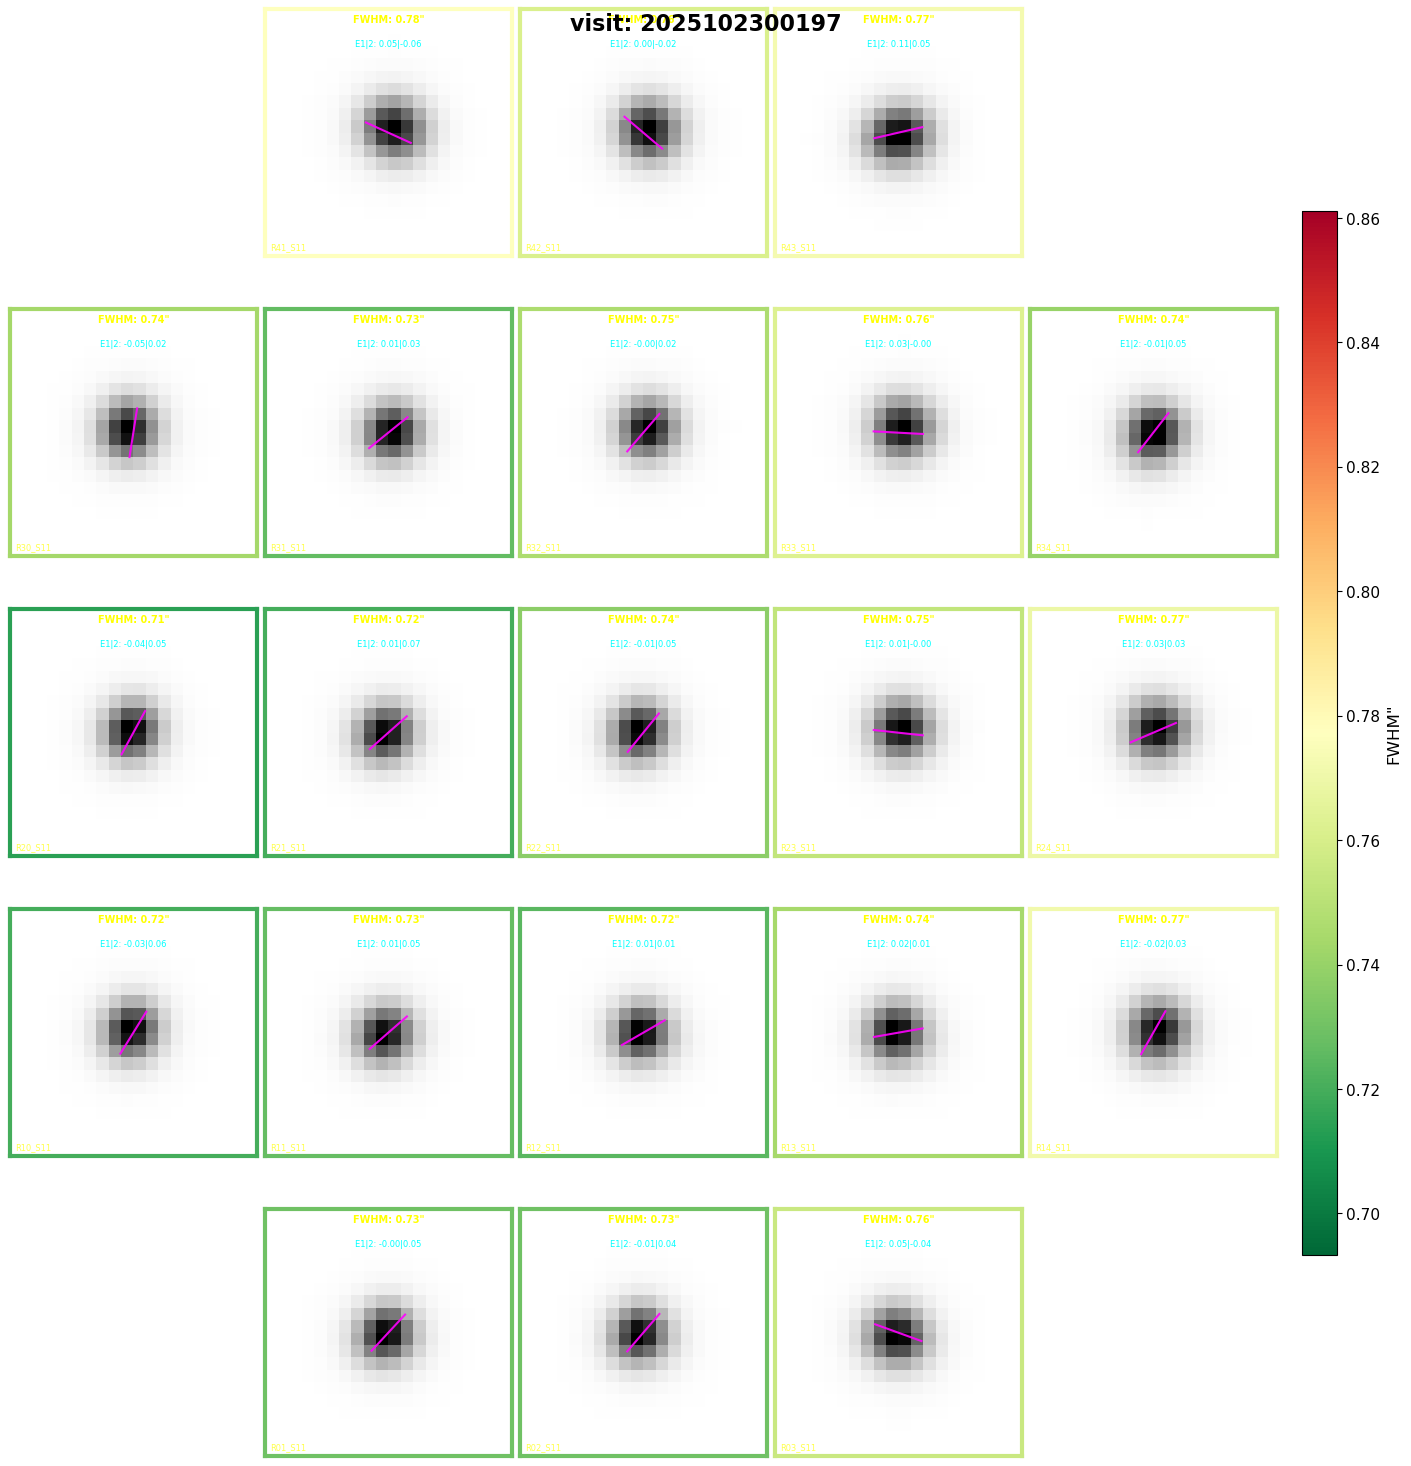

In [ ]:
# Generate PSF focal plane PNGs for each visit
print(f'Generating PSF mosaics for {len(visits_to_process)} visits...')

for i, (dobs, snum) in enumerate(visits_to_process):
    # Construct visit ID string
    visit_id = f'{dobs}{snum:05d}'
    band = band_lookup.get((dobs, snum), '')

    # Compute median Zernikes per detector
    det_zk = compute_median_zernikes_per_det(aosTable, dobs, snum)
    if not det_zk:
        print(f'  ({dobs}, {snum}): no data, skipping')
        continue

    save_path = output_dir / f'psf_mosaic_{visit_id}.png'

    # Show first visit inline, save all to files
    fig = plot_focal_plane_psfs(
        det_zk, visit_id=visit_id, band=band, save_path=save_path
    )

    if i == 0:
        plt.show()
    else:
        plt.close(fig)

    if (i + 1) % 10 == 0:
        print(f'  Processed {i + 1}/{len(visits_to_process)} visits')

print(f'Done. {len(visits_to_process)} PNGs saved to {output_dir}/')